# Reproduce Figure 11
This notebook reproduces Figure 11, warm start E2E latency impact of 𝜆-trim. The figure can be produced with either data provided by authors (`paper_results`) or data collected by the user (`results`).

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
use_provided_data = True # Set to True if you want to use the provided data, False to use data collected from the script
RESULTS_DIR = Path("paper_results") if use_provided_data else Path("results")
DEBLOATED_DIR = RESULTS_DIR / Path("debloated_warm")
ORIGINAL_DIR = RESULTS_DIR  / Path("baseline_warm")
OUTPUT_DIR = Path("figures")

In [9]:
PRICE_PER_MS_PER_MB_PER_100K_REQ = 0.00000162109
def get_estimated_cost(mem, time):
    # mem in MB, time in ms
    if mem < 128:
        mem = 128
    return mem * PRICE_PER_MS_PER_MB_PER_100K_REQ * time

In [10]:
def get_app_latency(app_name: str):
    print(f"Collecting data for {app_name}")
    # find the baseline warm start result

    if not (ORIGINAL_DIR / f"{app_name}.csv").exists():
        print(f"Error: Unable to find warm start data for {app_name}")
        return

    original_time = pd.read_csv(ORIGINAL_DIR / f"{app_name}.csv")[
        "e2e_latency"
    ].mean()

    
    debloated_time = pd.read_csv(DEBLOATED_DIR / f"{app_name}-debloat.csv")[
        "e2e_latency"
    ].mean()


    return (original_time, debloated_time)

In [11]:
apps = [d.name[:-12] for d in DEBLOATED_DIR.iterdir()]
apps.sort()
print(f"Collected applications (total {len(apps)}): {' '.join(apps)}")

Collected applications (total 21): chdb-olap dna-visualization epub-pdf ffmpeg huggingface igraph image-resize jsym lightgbm lxml markdown pandas qiskit-nature resnet scikit shapely-numpy skimage spacy tensorflow textblob wine


In [13]:
data = {"apps": apps, "original": [], "debloated": []}
for app in apps:
    original, debloated = get_app_latency(app)
    data["original"].append(original)
    data["debloated"].append(debloated)
data = pd.DataFrame(data)

## Plotting

<Figure size 640x480 with 0 Axes>

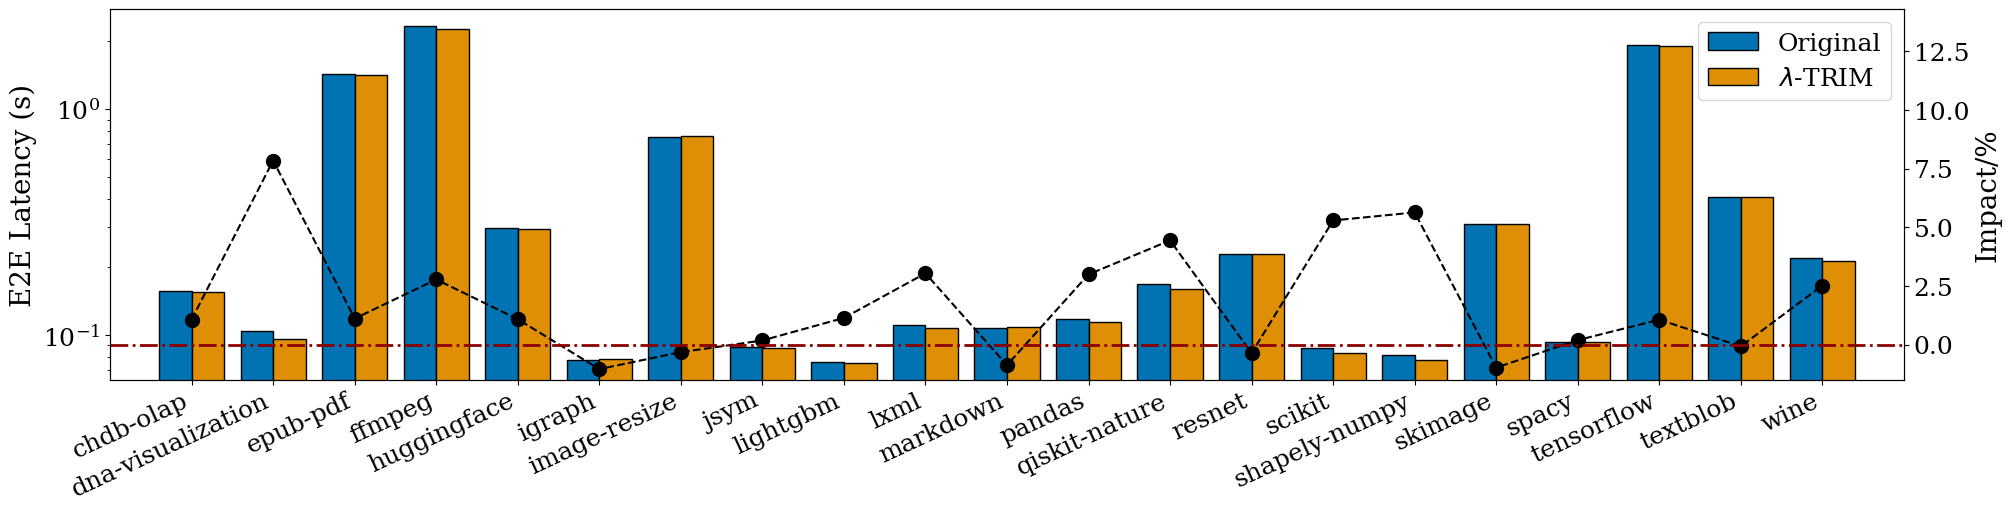

In [14]:
plt.rc("font", size=18, family="serif")
def plot_data(
    data: pd.DataFrame,
):
    apps = data["apps"]

    improvment = [
        (ori - deb) * 100 / ori
        for (ori, deb) in zip(data["original"], data["debloated"])
    ]

    x_axis = np.arange(len(apps))

    plt.clf()
    fig, ax_main = plt.subplots(figsize=(20, 5), layout="constrained")

    ax_main.bar(
        x_axis - 0.2,
        data["original"],
        0.4,
        label="Original",
        edgecolor="k"
    )
    ax_main.bar(
        x_axis + 0.2,
        data["debloated"],
        0.4,
        label="$\\lambda$-TRIM",
        edgecolor="k"
    )
    ax_main.set_xticks(x_axis, apps, rotation=25, ha="right")
    ax_main.set_ylabel("E2E Latency (s)", fontsize=20)
    ax_main.set_yscale("log")

    ax_impr = ax_main.twinx()
    ax_impr.plot(x_axis, improvment, color="black", marker="o", linestyle="--", markersize=10)
    _extended_x_axis = np.arange(-1, len(apps) + 1)
    ax_impr.plot(
        _extended_x_axis,
        np.zeros_like(_extended_x_axis),
        color="darkred",
        linestyle="-.",
        linewidth=2,
    )
    ax_impr.set_xlim(-1, len(apps))
    ax_impr.set_ylabel("Impact/%", fontsize=20)
    ymin, ymax = ax_impr.set_ylim()
    ax_impr.set_ylim(ymin, ymax + 6)

    ax_main.legend()
    plt.savefig(OUTPUT_DIR / f"fig11.pdf")
    plt.show()
with sns.color_palette("colorblind"):
    plot_data(data)